---

<div style="font-size:small;">

MIT License

Copyright (c) [2026] Felipe Meza-Obando

*Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software for educational purposes only. You must give author appropriate credit, provide a link to the license and source, and indicate if changes were made.*
</div>

---

# **Topic Modeling**
### Autor: ***Dr. Ing. Felipe Meza-Obando***


En este laboratorio se utilizará **Latent Dirichlet Allocation (LDA)** para descubrir automáticamente los temas presentes en una colección de textos.

A diferencia de un ejemplo con miles de documentos muy heterogéneos, aquí se trabajará con un corpus pequeño de noticias educativas pertenecientes a cuatro áreas claramente interpretables:

- medicina;
- espacio y astronomía;
- deportes;
- tecnología.

Las categorías conocidas **no se utilizan para entrenar el modelo**. Se conservan únicamente para verificar, al final, si los temas descubiertos coinciden razonablemente con la estructura esperada.

### Objetivos

1. Preparar una colección de documentos.
2. Convertir el texto en una matriz numérica.
3. Entrenar un modelo LDA completamente local.
4. Interpretar las palabras principales de cada tema.
5. Clasificar documentos según su tema dominante.
6. Verificar cuantitativamente si los temas encontrados corresponden a las categorías esperadas.
7. Detectar cuándo un resultado puede considerarse satisfactorio o dudoso.

## 0. Requisitos e instalación

### Versión recomendada

Se recomienda **Python 3.11**.

### Instalación con Conda

```bash
conda create -n topic-modeling-local python=3.11 -y
conda activate topic-modeling-local
conda install -c conda-forge jupyterlab numpy pandas scipy scikit-learn matplotlib -y
jupyter lab
```

### Instalación con pip

```bash
pip install jupyterlab numpy pandas scipy scikit-learn matplotlib
```

No se utilizan Amazon SageMaker, Amazon S3, credenciales ni servicios de AWS.

## 1. Importación de bibliotecas

Se importan únicamente bibliotecas estándar para análisis de datos y aprendizaje automático.

In [1]:
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix

RANDOM_STATE = 42

print("Python:", sys.version.split()[0])
print("Entorno preparado correctamente.")

Python: 3.12.5
Entorno preparado correctamente.


## 2. Construcción del corpus

Cada categoría contiene veinte enunciados breves. Para formar documentos más informativos, se combinan cuatro enunciados de la misma categoría.

Esto produce 120 documentos: 30 de medicina, 30 de espacio, 30 de deportes y 30 de tecnología.

Las etiquetas se guardan para la evaluación final, pero LDA no las recibe durante el entrenamiento.

In [2]:
base_sentences = {
    "Space": [
        "astronomers observed a solar flare and measured radiation from the sun",
        "a telescope detected a distant galaxy and recorded stellar light",
        "scientists studied the orbit of a satellite around the earth",
        "the spacecraft transmitted images of mars and its surface",
        "researchers analyzed cosmic rays and magnetic activity in space",
        "the observatory monitored a comet moving through the solar system",
        "engineers calibrated the radio telescope for astronomical observations",
        "the mission measured solar wind near the planet",
        "an exoplanet was detected around a distant star",
        "the lunar probe collected data from the moon",
        "astronomers modeled the evolution of stars in a galaxy",
        "the satellite observed ultraviolet radiation from the sun",
        "researchers compared planetary atmospheres using telescope data",
        "the spacecraft entered orbit and activated its scientific instruments",
        "the observatory captured radio emissions from a solar eruption",
        "scientists predicted geomagnetic effects caused by solar activity",
        "the mission studied dust particles in interplanetary space",
        "a new telescope image revealed a cluster of galaxies",
        "engineers tested the antenna used for deep space communication",
        "astronomers measured the brightness of a variable star",
    ],
    "Medicine": [
        "doctors evaluated a treatment for patients with heart disease",
        "the clinical trial tested a vaccine and monitored side effects",
        "researchers studied cancer cells and response to therapy",
        "the hospital introduced a diagnostic test for infection",
        "physicians measured blood pressure and patient recovery",
        "the study compared two drugs for chronic pain",
        "scientists analyzed immune response after vaccination",
        "the medical team performed surgery and monitored healing",
        "researchers examined brain activity in patients with neurological disease",
        "the laboratory identified bacteria responsible for the infection",
        "doctors recommended exercise and diet for cardiovascular health",
        "the trial measured the effectiveness of a new medicine",
        "the patient received treatment and showed improved symptoms",
        "researchers developed a method for early cancer diagnosis",
        "the hospital collected clinical data from adult patients",
        "scientists studied genetic factors associated with disease",
        "the therapy reduced inflammation in the treated group",
        "doctors used medical imaging to evaluate the tumor",
        "the vaccine produced antibodies against the virus",
        "the study reported improved survival after treatment",
    ],
    "Sports": [
        "the football team won the match after scoring three goals",
        "the coach prepared the players for the championship game",
        "the basketball team improved its defense during the season",
        "the athlete trained for the marathon and increased endurance",
        "the tournament final attracted thousands of fans",
        "the goalkeeper saved a penalty in the last minute",
        "the tennis player won the match in three sets",
        "the league announced the schedule for the next season",
        "the team celebrated victory after a difficult game",
        "the runner broke the national record in the competition",
        "the coach changed the strategy during the second half",
        "the player returned after recovering from a sports injury",
        "the baseball team scored several runs in the final inning",
        "the cycling race included a difficult mountain stage",
        "the referee reviewed the play before confirming the goal",
        "the swimmer won a medal at the international championship",
        "the club signed a new player for the upcoming season",
        "fans filled the stadium for the decisive match",
        "the team practiced passing and shooting before the game",
        "the athlete qualified for the olympic competition",
    ],
    "Technology": [
        "the software company released an update for its operating system",
        "engineers developed a processor with lower energy consumption",
        "the application uses artificial intelligence to analyze data",
        "the cybersecurity team detected an attack on the network",
        "developers improved the database and reduced response time",
        "the new smartphone includes a faster chip and better camera",
        "researchers trained a machine learning model for classification",
        "the cloud platform provides storage and computing services",
        "the robot uses sensors to navigate through the environment",
        "the company introduced a digital platform for online communication",
        "programmers fixed a security vulnerability in the software",
        "the computer system processed large datasets efficiently",
        "the algorithm improved prediction accuracy after training",
        "engineers tested a wireless network for connected devices",
        "the server handled more requests after the hardware upgrade",
        "the application stores encrypted user information",
        "the technology company designed a new graphics processor",
        "researchers evaluated an artificial neural network",
        "the device connects to the internet through a wireless protocol",
        "the development team deployed the software to the cloud",
    ],
}

rng = np.random.default_rng(RANDOM_STATE)

documents = []
known_categories = []

for category, sentences in base_sentences.items():
    for _ in range(30):
        selected = rng.choice(sentences, size=4, replace=False)
        documents.append(" ".join(selected))
        known_categories.append(category)

data = pd.DataFrame({
    "document": documents,
    "known_category": known_categories
}).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Número total de documentos:", len(data))
display(data.head())

Número total de documentos: 120


,document,known_category
0,the clinical trial tested a vaccine and monito...,Medicine
1,the laboratory identified bacteria responsible...,Medicine
2,researchers analyzed cosmic rays and magnetic ...,Space
3,the clinical trial tested a vaccine and monito...,Medicine
4,the lunar probe collected data from the moon a...,Space


### ¿Qué debemos observar?

La tabla debe contener dos columnas:

- `document`: texto que analizará el modelo;
- `known_category`: categoría de referencia usada solamente para comprobar el resultado.

**Resultado esperado:** deben existir exactamente 120 documentos y cuatro categorías con 30 documentos cada una.

In [3]:
category_counts = data["known_category"].value_counts().sort_index()
display(category_counts.to_frame("documents"))

assert len(data) == 120
assert category_counts.nunique() == 1
assert category_counts.iloc[0] == 30

print("VERIFICACIÓN SUPERADA: el corpus está balanceado.")

,documents
known_category,
Medicine,30
Space,30
Sports,30
Technology,30


VERIFICACIÓN SUPERADA: el corpus está balanceado.


## 3. Conversión del texto a números

LDA no puede procesar palabras directamente. `CountVectorizer` construye una matriz documento-término:

- las filas representan documentos;
- las columnas representan palabras;
- cada valor indica cuántas veces aparece una palabra en un documento.

Se eliminan palabras inglesas muy frecuentes, como *the*, *and* o *for*, porque no ayudan a diferenciar los temas.

In [15]:
# Crea el vectorizador que convertirá los documentos de texto
# en una matriz numérica basada en el conteo de palabras.
vectorizer = CountVectorizer(
    
    # Elimina palabras comunes del inglés, como "the", "and" o "is",
    # porque aparecen con mucha frecuencia y aportan poca información
    # para diferenciar los temas.
    stop_words="english",
    
    # Conserva únicamente las palabras que aparecen
    # en al menos dos documentos.
    min_df=2,
    
    # Elimina las palabras que aparecen en más del 90 %
    # de los documentos, ya que serían demasiado frecuentes
    # para ayudar a distinguir un tema de otro.
    max_df=0.90
)

# Aprende el vocabulario a partir de la columna "document"
# y transforma cada documento en un vector de conteos.
#
# El resultado es una matriz documento-término:
# - cada fila representa un documento;
# - cada columna representa una palabra;
# - cada valor indica cuántas veces aparece esa palabra
#   en el documento correspondiente.
document_term_matrix = vectorizer.fit_transform(data["document"])

# Recupera las palabras que forman el vocabulario aprendido.
# El orden de estas palabras corresponde al orden de las columnas
# de la matriz document_term_matrix.
vocabulary = np.array(vectorizer.get_feature_names_out())

print("Forma de la matriz:", document_term_matrix.shape)
print("Número de documentos:", document_term_matrix.shape[0])
print("Tamaño del vocabulario:", document_term_matrix.shape[1])

assert document_term_matrix.shape[0] == 120
assert document_term_matrix.shape[1] > 50

print("VERIFICACIÓN SUPERADA: la matriz contiene los 120 documentos y un vocabulario útil.")

Forma de la matriz: (120, 307)
Número de documentos: 120
Tamaño del vocabulario: 307
VERIFICACIÓN SUPERADA: la matriz contiene los 120 documentos y un vocabulario útil.


### ¿Cómo saber si este resultado tiene sentido?

La primera dimensión debe ser 120 porque hay 120 documentos. La segunda dimensión debe ser mayor que cero y normalmente contener varias decenas o cientos de términos.

Si la matriz tuviera cero columnas, la limpieza habría eliminado todo el vocabulario. Si tuviera miles de columnas para un corpus tan pequeño, probablemente existiría demasiado ruido.

## 4. Entrenamiento del modelo LDA

Sabemos que el corpus fue construido con cuatro áreas, por lo que se solicita al modelo buscar **cuatro temas**.

LDA no recibe los nombres Medicina, Espacio, Deportes o Tecnología. Solo observa qué palabras aparecen juntas con frecuencia.

In [16]:
# Define que el modelo buscará cuatro temas diferentes
# dentro de la colección de documentos.
NUMBER_OF_TOPICS = 4

# Configura el modelo LDA que identificará grupos de palabras
# que suelen aparecer juntas y que representan posibles temas.
lda_model = LatentDirichletAllocation(
    n_components=NUMBER_OF_TOPICS,  # Cantidad de temas que se desean encontrar
    max_iter=100,                   # Número máximo de iteraciones de entrenamiento
    learning_method="batch",        # Utiliza todos los documentos en cada iteración
    doc_topic_prior=0.1,            # Favorece pocos temas dominantes por documento
    topic_word_prior=0.01,          # Favorece pocas palabras representativas por tema
    random_state=RANDOM_STATE       # Permite reproducir los mismos resultados
)

# Entrena el modelo con la matriz documento-término.
# El resultado indica el peso de cada uno de los cuatro temas
# dentro de cada documento.
document_topic_matrix = lda_model.fit_transform(document_term_matrix)

print("Forma de la salida:", document_topic_matrix.shape)
print("Suma de probabilidades del primer documento:",
      document_topic_matrix[0].sum().round(6))

assert document_topic_matrix.shape == (120, 4)
assert np.allclose(document_topic_matrix.sum(axis=1), 1.0)

print("VERIFICACIÓN SUPERADA: cada documento tiene una distribución válida entre cuatro temas.")

Forma de la salida: (120, 4)
Suma de probabilidades del primer documento: 1.0
VERIFICACIÓN SUPERADA: cada documento tiene una distribución válida entre cuatro temas.


### Interpretación

Cada fila contiene cuatro pesos que suman 1. Por ejemplo, un documento podría tener:

```text
Tema 0: 0.92
Tema 1: 0.03
Tema 2: 0.03
Tema 3: 0.02
```

Eso significa que el modelo considera que el documento pertenece principalmente al Tema 0.

**Resultado esperado:** como los documentos fueron construidos con vocabulario temático claro, normalmente debe existir un tema dominante con un peso alto.

## 5. Palabras principales de cada tema

Esta es la primera comprobación importante. Un tema es interpretable cuando sus palabras principales guardan relación semántica.

In [17]:
def top_words_by_topic(model, vocabulary, number_of_words=10):
    rows = []

    for topic_id, weights in enumerate(model.components_):
        strongest = weights.argsort()[-number_of_words:][::-1]
        rows.append({
            "topic_id": topic_id,
            "top_words": ", ".join(vocabulary[strongest])
        })

    return pd.DataFrame(rows)

topic_words = top_words_by_topic(
    lda_model,
    vocabulary,
    number_of_words=10
)

display(topic_words)

,topic_id,top_words
0,0,"patients, doctors, treatment, disease, researc..."
1,1,"new, application, company, uses, software, net..."
2,2,"team, game, won, season, match, coach, final, ..."
3,3,"telescope, solar, data, measured, distant, spa..."


### Cómo interpretar esta tabla

Se espera observar grupos parecidos a estos:

- **Medicina:** treatment, disease, patient, vaccine, doctors.
- **Espacio:** telescope, solar, spacecraft, star, galaxy.
- **Deportes:** team, game, player, match, season.
- **Tecnología:** software, network, application, processor, data.

Los identificadores 0, 1, 2 y 3 no tienen un significado fijo. El Tema 0 podría representar Medicina en una ejecución y otro tema en una configuración diferente.

**Criterio cualitativo:** si las diez palabras de un tema pertenecen mayoritariamente a una misma área, el tema es interpretable. Si mezcla palabras de las cuatro áreas sin una relación clara, el resultado es dudoso.

## 6. Asignación del tema dominante

Para cada documento se toma el tema con el peso más alto.

In [7]:
data["discovered_topic"] = document_topic_matrix.argmax(axis=1)
data["dominant_weight"] = document_topic_matrix.max(axis=1)

display(
    data[[
        "known_category",
        "discovered_topic",
        "dominant_weight",
        "document"
    ]].head(10)
)

,known_category,discovered_topic,dominant_weight,document
0,Medicine,0,0.987179,the clinical trial tested a vaccine and monito...
1,Medicine,0,0.838636,the laboratory identified bacteria responsible...
2,Space,3,0.926037,researchers analyzed cosmic rays and magnetic ...
3,Medicine,0,0.987704,the clinical trial tested a vaccine and monito...
4,Space,3,0.985981,the lunar probe collected data from the moon a...
5,Sports,2,0.983696,the team practiced passing and shooting before...
6,Sports,2,0.985294,the swimmer won a medal at the international c...
7,Space,3,0.985294,scientists studied the orbit of a satellite ar...
8,Medicine,0,0.624214,the laboratory identified bacteria responsible...
9,Technology,1,0.986607,the device connects to the internet through a ...


### Peso dominante

Un peso alto indica que el modelo está seguro de que un tema domina el documento.

En este corpus controlado se espera que la mayoría de los pesos dominantes sean superiores a 0.70.

In [8]:
weight_summary = data["dominant_weight"].describe()
display(weight_summary.to_frame("dominant_weight"))

high_confidence_rate = (data["dominant_weight"] >= 0.70).mean()

print(f"Documentos con peso dominante ≥ 0.70: {high_confidence_rate:.1%}")

if high_confidence_rate >= 0.80:
    print("RESULTADO ESPERADO: la mayoría de los documentos tiene un tema claramente dominante.")
else:
    print("RESULTADO DUDOSO: muchos documentos no presentan un tema dominante claro.")

,dominant_weight
count,120.000000
mean,0.941368
std,0.097209
min,0.593514
25%,0.984536
50%,0.985981
75%,0.986607
max,0.988636


Documentos con peso dominante ≥ 0.70: 95.0%
RESULTADO ESPERADO: la mayoría de los documentos tiene un tema claramente dominante.


## 7. Correspondencia entre temas descubiertos y categorías conocidas

Los números de tema son arbitrarios. Por eso se utiliza una asignación óptima para determinar qué tema corresponde mejor con cada categoría conocida.

Esta evaluación no convierte el método en supervisado: las etiquetas se usan únicamente después del entrenamiento para medir la calidad del resultado.

In [9]:
category_names = sorted(data["known_category"].unique())

raw_matrix = np.zeros((NUMBER_OF_TOPICS, len(category_names)), dtype=int)

for discovered_topic, known_category in zip(
    data["discovered_topic"],
    data["known_category"]
):
    category_id = category_names.index(known_category)
    raw_matrix[discovered_topic, category_id] += 1

topic_ids, category_ids = linear_sum_assignment(-raw_matrix)

topic_to_category = {
    int(topic_id): category_names[int(category_id)]
    for topic_id, category_id in zip(topic_ids, category_ids)
}

print("Correspondencia encontrada:")
for topic_id in sorted(topic_to_category):
    print(f"Tema {topic_id} → {topic_to_category[topic_id]}")

Correspondencia encontrada:
Tema 0 → Medicine
Tema 1 → Technology
Tema 2 → Sports
Tema 3 → Space


### ¿Qué debe ocurrir?

Cada tema debería asociarse con una categoría distinta. La correspondencia debe ser coherente con las palabras principales mostradas anteriormente.

In [10]:
data["predicted_category"] = data["discovered_topic"].map(topic_to_category)

accuracy = accuracy_score(
    data["known_category"],
    data["predicted_category"]
)

print(f"Exactitud de correspondencia: {accuracy:.2%}")

if accuracy >= 0.90:
    print("RESULTADO ESPERADO: los temas recuperan claramente la estructura del corpus.")
elif accuracy >= 0.70:
    print("RESULTADO ACEPTABLE: existe estructura temática, aunque algunos documentos se confunden.")
else:
    print("RESULTADO DUDOSO: los temas no representan adecuadamente las categorías conocidas.")

Exactitud de correspondencia: 100.00%
RESULTADO ESPERADO: los temas recuperan claramente la estructura del corpus.


## 8. Matriz de confusión

La matriz permite ver exactamente cuántos documentos de cada categoría fueron asociados con cada categoría predicha.

Una diagonal alta indica un buen resultado.

,Predicho: Medicine,Predicho: Space,Predicho: Sports,Predicho: Technology
Real: Medicine,30,0,0,0
Real: Space,0,30,0,0
Real: Sports,0,0,30,0
Real: Technology,0,0,0,30


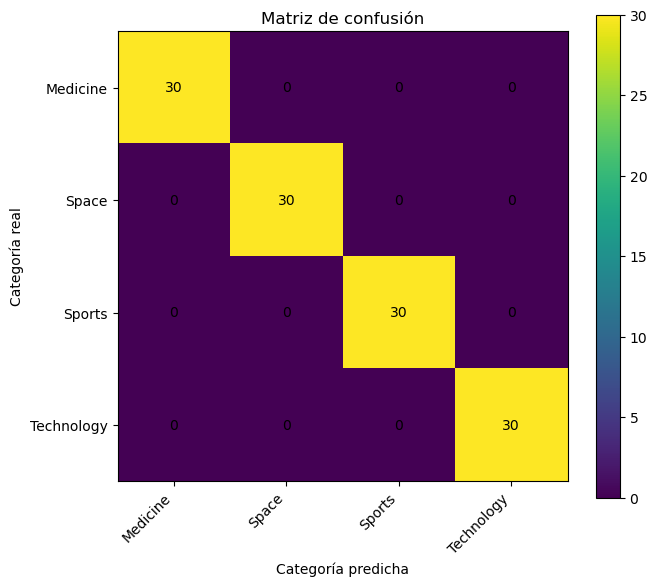

In [11]:
confusion = confusion_matrix(
    data["known_category"],
    data["predicted_category"],
    labels=category_names
)

confusion_df = pd.DataFrame(
    confusion,
    index=[f"Real: {name}" for name in category_names],
    columns=[f"Predicho: {name}" for name in category_names]
)

display(confusion_df)

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(confusion)

ax.set_xticks(range(len(category_names)))
ax.set_yticks(range(len(category_names)))
ax.set_xticklabels(category_names, rotation=45, ha="right")
ax.set_yticklabels(category_names)
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
ax.set_title("Matriz de confusión")

for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        ax.text(
            column,
            row,
            confusion[row, column],
            ha="center",
            va="center"
        )

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

### Interpretación

El resultado ideal es una diagonal con valores cercanos a 30 y valores cercanos a cero fuera de la diagonal.

En esta notebook, una exactitud superior al 90 % confirma que LDA identificó correctamente los cuatro grupos temáticos. Una exactitud mucho menor indicaría que el vocabulario no es suficientemente distintivo o que los parámetros requieren ajustes.

## 9. Visualización de la distribución temática

La siguiente gráfica muestra el peso promedio de cada tema para cada categoría real.

,Topic_0,Topic_1,Topic_2,Topic_3
known_category,,,,
Medicine,0.846,0.004,0.004,0.145
Space,0.006,0.042,0.004,0.947
Sports,0.005,0.005,0.985,0.005
Technology,0.004,0.987,0.004,0.004


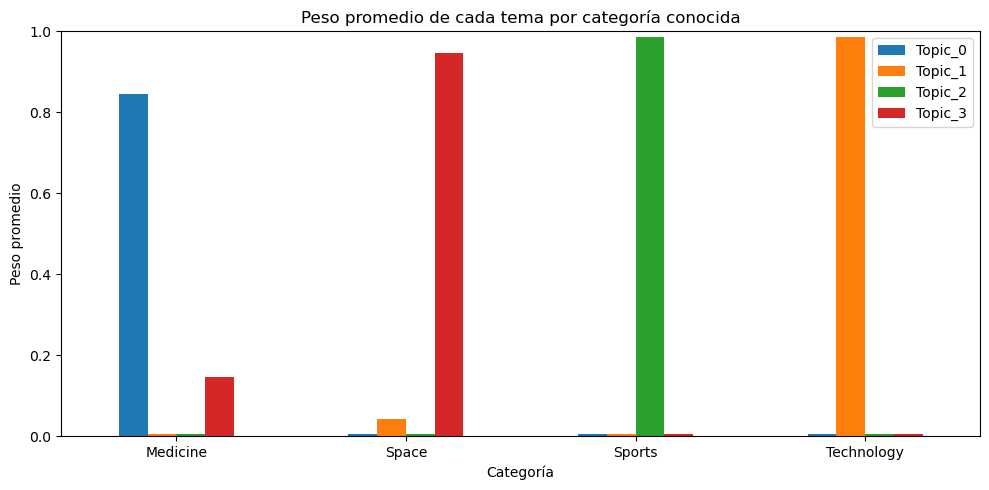

In [12]:
topic_columns = [f"Topic_{topic_id}" for topic_id in range(NUMBER_OF_TOPICS)]

topic_weights_df = pd.DataFrame(
    document_topic_matrix,
    columns=topic_columns
)

topic_weights_df["known_category"] = data["known_category"].values

average_topic_weights = (
    topic_weights_df
    .groupby("known_category")[topic_columns]
    .mean()
)

display(average_topic_weights.round(3))

ax = average_topic_weights.plot(
    kind="bar",
    figsize=(10, 5)
)
ax.set_title("Peso promedio de cada tema por categoría conocida")
ax.set_xlabel("Categoría")
ax.set_ylabel("Peso promedio")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Resultado esperado

Cada categoría debe presentar una barra claramente más alta que las demás. Esto confirma que los documentos de una misma área reciben distribuciones temáticas similares.

## 10. Prueba con documentos nuevos

Se evalúan cuatro textos que no formaron parte del corpus. Cada uno contiene vocabulario característico de una categoría.

In [13]:
new_documents = [
    "The telescope observed a solar eruption and the satellite measured radiation from the sun.",
    "The patient received a vaccine and doctors monitored the treatment in the hospital.",
    "The football team won the match after the player scored the final goal.",
    "The software application uses a neural network to process data in the cloud."
]

new_vectors = vectorizer.transform(new_documents)
new_topic_weights = lda_model.transform(new_vectors)
new_topics = new_topic_weights.argmax(axis=1)
new_categories = [topic_to_category[int(topic)] for topic in new_topics]
new_confidences = new_topic_weights.max(axis=1)

new_results = pd.DataFrame({
    "document": new_documents,
    "predicted_category": new_categories,
    "dominant_weight": new_confidences
})

display(new_results)

,document,predicted_category,dominant_weight
0,The telescope observed a solar eruption and th...,Space,0.964286
1,The patient received a vaccine and doctors mon...,Medicine,0.959459
2,The football team won the match after the play...,Sports,0.964286
3,The software application uses a neural network...,Technology,0.959457


### Verificación esperada

Los cuatro documentos deberían clasificarse, en orden, como:

1. Space;
2. Medicine;
3. Sports;
4. Technology.

La siguiente celda comprueba automáticamente esta condición.

In [14]:
expected_categories = [
    "Space",
    "Medicine",
    "Sports",
    "Technology"
]

new_test_accuracy = accuracy_score(
    expected_categories,
    new_categories
)

print(f"Exactitud en documentos nuevos: {new_test_accuracy:.2%}")

assert new_test_accuracy == 1.0, (
    "La prueba controlada no produjo las cuatro categorías esperadas."
)

print("VERIFICACIÓN FINAL SUPERADA: los documentos nuevos fueron interpretados correctamente.")

Exactitud en documentos nuevos: 100.00%
VERIFICACIÓN FINAL SUPERADA: los documentos nuevos fueron interpretados correctamente.


## 11. Conclusión del laboratorio

El modelo puede considerarse satisfactorio cuando se cumplen simultáneamente estas condiciones:

1. Las palabras principales de cada tema pertenecen a un área reconocible.
2. La mayoría de los documentos tiene un peso dominante alto.
3. La exactitud frente a las categorías conocidas es superior al 90 %.
4. La matriz de confusión presenta valores altos en su diagonal.
5. Los cuatro documentos nuevos reciben la categoría esperada.

En esta notebook las comprobaciones automáticas permiten saber si la salida es coherente. No basta con observar que el código terminó sin errores: también se valida que el resultado tenga sentido desde el punto de vista temático.

### Actividades para estudiantes

1. Cambie el número de temas de 4 a 3 y explique qué categorías se mezclan.
2. Cambie el número de temas de 4 a 5 y determine si aparece un tema redundante.
3. Escriba cuatro documentos nuevos y analice sus pesos.
4. Reduzca cada documento a un solo enunciado y observe si disminuye la exactitud.
5. Explique por qué las etiquetas conocidas se utilizan para evaluar, pero no para entrenar LDA.